# F12: Potensialfunksjoner og strømlinjer

Denne notatboken bygger direkte videre på `F11_Gradient_Vektorfelt_Divergens_Curl.ipynb` (vektorfelt, gradient, divergens og curl). Her ser vi på

1. **potensialfunksjoner** -- hvordan vi finner en funksjon $f$ slik at $\vec F=\nabla f$, og hva det betyr at et slikt felt er **rotasjonsfritt**,
2. **strømlinjer/baner** til vektorfelt, inkludert et eksempel med kilde, sluk og ren rotasjon i samme felt.

Den presise definisjonen av **konservative vektorfelt** -- og en advarsel om at curl$=0$ ikke alltid er nok til å garantere det -- kommer i `F13`, når vi har linjeintegraler til å regne med.

Dette bygger på `operators_sympy.ipynb`, `Vektorfelt Visualisering.ipynb` og kompendiets kapittel om potensialer og vektorfelt.

In [1]:
import numpy as np                      # numerisk regning (arrays, rutenett, ...)
import matplotlib.pyplot as plt         # plotting (quiver, streamplot, contour, ...)
import sympy as sp                      # symbolsk regning (integrasjon, derivasjon, ...)
from scipy.integrate import solve_ivp   # numerisk løsning av differensiallikninger (baner/strømlinjer)

%matplotlib inline
plt.rcParams["figure.figsize"] = (6, 6)   # default figurstørrelse for resten av notatboken

x, y = sp.symbols('x y')   # symbolske variable som brukes gjennom hele notatboken

## 1. Potensialfunksjoner

Fra `F11` husker vi at gradienten til en funksjon $f(x,y)$ er vektorfeltet $\nabla f=(f_x,f_y)$. Dersom et vektorfelt $\vec F=(P,Q)$ kan skrives som $\vec F=\nabla f$ for en funksjon $f$, kaller vi $f$ en **potensialfunksjon** for $\vec F$ (vi kommer tilbake til det presise begrepet *konservativt vektorfelt* i avsnitt 3).

### Oppskrift

Gitt $\vec F=(P,Q)$, ønsker vi å finne $f$ slik at $f_x=P$ og $f_y=Q$:

1. Integrer $P$ med hensyn på $x$: $f(x,y)=\int P\,dx + g(y)$, hvor $g(y)$ er en ukjent "integrasjonskonstant" som godt kan avhenge av $y$.
2. Deriver dette uttrykket med hensyn på $y$, og sammenlign med $Q$ for å finne $g'(y)$ -- og dermed $g(y)$.

La oss bygge dette som en liten Python-funksjon med Sympy, og teste den på $\vec F(x,y)=(2x,2y)$ (feltet vi kjenner igjen fra $f(x,y)=x^2+y^2$ i F11).

In [2]:
def finn_potensial(P_expr, Q_expr):
    '''Finner (om mulig) f slik at grad f = (P, Q), med Sympy.'''
    g = sp.Function('g')                 # g(y) er en ukjent funksjon -- "integrasjonskonstanten"
    f_kandidat = sp.integrate(P_expr, x) + g(y)   # steg 1: integrer P med hensyn på x

    # steg 2: f_y skal være lik Q -- løs likningen for g'(y)
    gprime = sp.solve(sp.Eq(sp.diff(f_kandidat, y), Q_expr), sp.diff(g(y), y))
    if not gprime:
        return None   # fant ingen løsning -- se avsnittet under om hva dette betyr
    g_expr = sp.integrate(gprime[0], y)   # integrer opp g'(y) for å finne g(y)

    f = sp.integrate(P_expr, x) + g_expr
    return sp.simplify(f)

P, Q = 2*x, 2*y                 # feltet vi tester på: F(x,y) = (2x, 2y)
f_funnet = finn_potensial(P, Q)
print("F = (2x, 2y)  ->  f =", f_funnet)

# Sjekk: gir gradienten til f tilbake feltet vårt? (den bør gjøre nøyaktig det)
print("Sjekk: grad f =", (sp.diff(f_funnet, x), sp.diff(f_funnet, y)))

F = (2x, 2y)  ->  f = x**2 + y**2
Sjekk: grad f = (2*x, 2*y)


Vi plotter potensialfunksjonen som nivåkurver, med gradientfeltet $\vec F=\nabla f$ lagt over -- akkurat som i gradient-avsnittet i F11. Legg merke til (igjen) at pilene står ortogonalt på nivåkurvene.

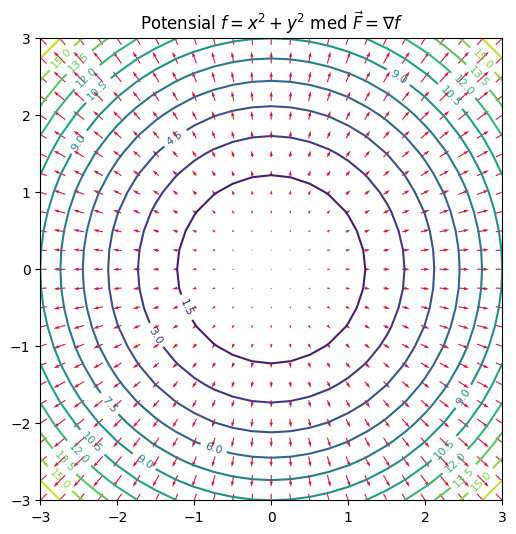

In [3]:
# lambdify: gjør de symbolske uttrykkene om til vanlige, raske Python-funksjoner
f_num = sp.lambdify((x, y), f_funnet, 'numpy')
P_num = sp.lambdify((x, y), P, 'numpy')
Q_num = sp.lambdify((x, y), Q, 'numpy')

xv = np.linspace(-3, 3, 25)
yv = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(xv, yv)

fig, ax = plt.subplots()
kontur = ax.contour(X, Y, f_num(X, Y), levels=12, cmap='viridis')   # nivåkurvene til f
ax.clabel(kontur, inline=True, fontsize=8)                           # skriv f-verdien på kurvene
ax.quiver(X, Y, P_num(X, Y), Q_num(X, Y), color='crimson', pivot='mid')   # gradientfeltet ∇f
ax.set_title(r"Potensial $f=x^2+y^2$ med $\vec F=\nabla f$")
ax.set_aspect('equal')
plt.show()

**Oppgave (løses i forelesningen):** Bruk `finn_potensial` på feltet $\vec F(x,y)=(y,x)$. Hvilken funksjon $f$ får du? Sjekk svaret for hånd.

In [4]:
# Skriv koden her


### Rotasjonsfrie felt

Fra "Noen identiteter" i kompendiet (og fra F11) vet vi at curl av et gradientfelt alltid er null: $\nabla\times(\nabla f)=\vec 0$. Et felt med $\operatorname{curl}\vec F=0$ overalt kalles **rotasjonsfritt** (eller *irrotasjonelt*) -- så ethvert gradientfelt er automatisk rotasjonsfritt. Vi lager en liten Sympy-sjekk av dette.

(Det motsatte spørsmålet -- om ethvert rotasjonsfritt felt faktisk *er* et gradientfelt -- er mer subtilt, og kommer vi tilbake til i F13, når vi har linjeintegraler å regne med.)

In [5]:
def curl_2d(P_expr, Q_expr):
    # curl F (2D, skalar) = dQ/dx - dP/dy
    return sp.simplify(sp.diff(Q_expr, x) - sp.diff(P_expr, y))

# Eksempel: F = (2x, 2y) -- vi fant jo potensialet f = x^2+y^2 i avsnitt 1
print("curl (2x, 2y) =", curl_2d(2*x, 2*y), "-> konsistent med at feltet er et gradientfelt")

curl (2x, 2y) = 0 -> konsistent med at feltet er et gradientfelt


## 2. Strømlinjer

En **bane** (eller strømlinje/trajectory) til et vektorfelt $\vec F$ gjennom et punkt $(x_0,y_0)$ er løsningen $\gamma(t)=(\gamma_1(t),\gamma_2(t))$ av differensiallikningen

$$\gamma'(t) = \vec F(\gamma(t)), \qquad \gamma(0) = (x_0,y_0).$$

Banen er altså en kurve som *følger pilene* i vektorfeltet i hvert punkt. Vi bruker `scipy.integrate.solve_ivp`, som i `Vektorfelt Visualisering.ipynb`.

### Strømlinjer til et gradientfelt

Før vi ser på mer generelle felt, er det verdt å legge merke til en fin sammenheng med avsnitt 1: siden $\nabla f$ står ortogonalt på nivåkurvene til $f$, må *strømlinjene* til et gradientfelt krysse nivåkurvene i rett vinkel overalt. For $f=x^2+y^2$ er strømlinjene til $\nabla f$ rett og slett rette linjer ut fra origo:

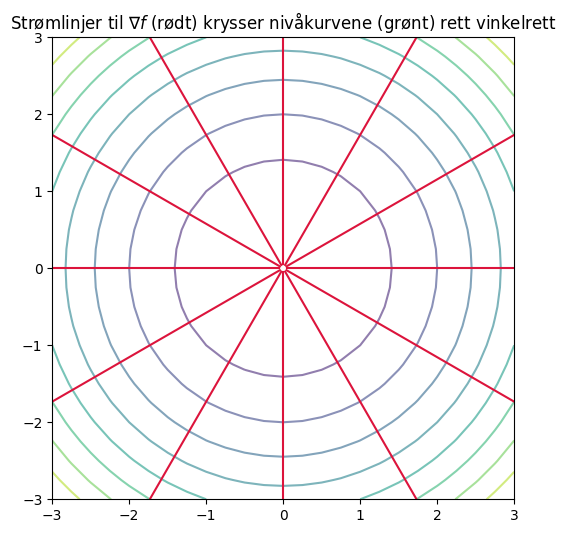

In [6]:
def grad_system(t, z):
    # høyresiden i banelikningen gamma'(t) = grad f(gamma(t)); z = (x, y) er posisjonen
    xx, yy = z
    return [P_num(xx, yy), Q_num(xx, yy)]

fig, ax = plt.subplots(figsize=(6, 6))
kontur = ax.contour(X, Y, f_num(X, Y), levels=8, cmap='viridis', alpha=0.6)   # nivåkurvene til f

theta = np.linspace(0, 2*np.pi, 12, endpoint=False)   # 12 startretninger rundt origo
T = 2.3  # nok til at r(T) = 0.05*exp(2T) ≈ 5, dvs. forbi hjørnene av [-3,3]x[-3,3]
t_eval = np.linspace(0, T, 200)
for th in theta:
    z0 = [0.05*np.cos(th), 0.05*np.sin(th)]                     # startpunkt: nær origo, i retning th
    sol = solve_ivp(grad_system, (0, T), z0, t_eval=t_eval)      # løs banelikningen numerisk
    ax.plot(sol.y[0], sol.y[1], color='crimson')                 # tegn banen (strømlinjen)

ax.set_xlim(xv.min(), xv.max())
ax.set_ylim(yv.min(), yv.max())
ax.set_title(r"Strømlinjer til $\nabla f$ (rødt) krysser nivåkurvene (grønt) rett vinkelrett")
ax.set_aspect('equal')
plt.show()

### Et pendel-eksempel

Nå ser vi på et vektorfelt som *ikke* er et gradientfelt: $\vec F(x,y)=(y,-\sin x)$, som er faseportrettet til en matematisk pendel.

**Kompendium-kobling:** dette er nettopp JuPyter-notatet det henvises til fra **Eksempel 2.5** i kompendiet (kapittel 2, avsnittet om divergens og rotasjon): feltet $\vec F(x,y)=y\,\vec\imath-\sin(x)\,\vec\jmath$ og systemet $x'(t)=y(t),\ y'(t)=-\sin(x(t))$, løst numerisk med `solve_ivp`.

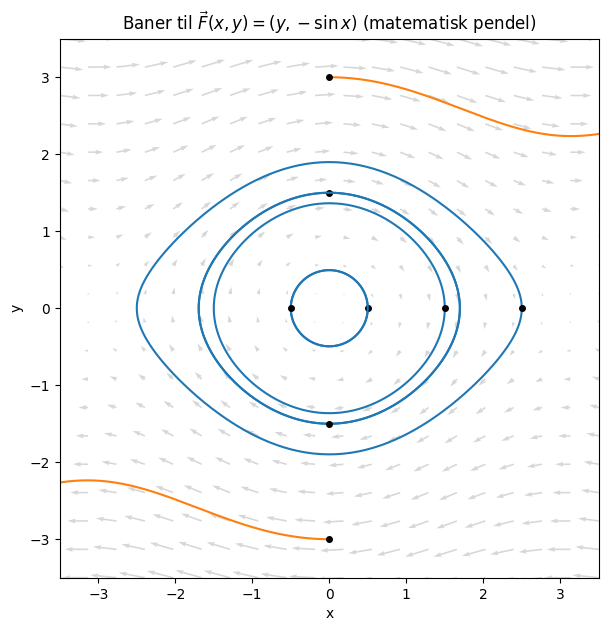

In [7]:
def F2(x, y):
    return y, -np.sin(x)   # faseportrettet til pendelen: F(x,y) = (y, -sin x)

def system(t, z):
    # høyresiden i banelikningen: z = (x, y) = (utslag, vinkelhastighet)
    x, y = z
    u, v = F2(x, y)
    return [u, v]

from scipy.special import ellipk   # den fullstendige elliptiske integralen K(m)

def periode_pendel(x0, y0):
    '''Periode for den lukkede pendelbanen gjennom (x0, y0), via elliptisk integral.
    Returnerer None hvis E >= 1 (pendelen har nok energi til å rulle over toppunktet).'''
    E = 0.5*y0**2 - np.cos(x0)   # bevart energi langs banen
    if E >= 1:
        return None
    theta_max = np.arccos(-E)                     # vendepunktet (maksimalt utslag)
    return 4*ellipk(np.sin(theta_max/2)**2)        # den klassiske pendelperiode-formelen

xv = np.linspace(-3.5, 3.5, 20)
yv = np.linspace(-3.5, 3.5, 20)
X, Y = np.meshgrid(xv, yv)
U, V = F2(X, Y)

fig, ax = plt.subplots(figsize=(7, 7))
ax.quiver(X, Y, U, V, color='lightgray', alpha=0.9)   # bakgrunn: feltet selv, i lys grå

# Svingende baner (E<1): integrer over nøyaktig én periode, slik at kurven lukker seg
svingende = [(0.5, 0), (1.5, 0), (2.5, 0), (-0.5, 0), (0, 1.5), (0, -1.5)]
for (x0, y0) in svingende:
    T = periode_pendel(x0, y0)                        # nøyaktig tid for én hel svingning
    t_eval = np.linspace(0, T, 400)
    sol = solve_ivp(system, (0, T), [x0, y0], t_eval=t_eval, rtol=1e-9, atol=1e-9)
    ax.plot(sol.y[0], sol.y[1], color='tab:blue')      # selve banen (blir en lukket kurve)
    ax.plot(x0, y0, 'o', color='black', ms=4)          # marker startpunktet

# Rullende baner (E>1): pendelen har nok energi til å gå heltrundt -- ingen lukket kurve,
# vi plotter derfor bare et utsnitt over en fast (kort) tid i stedet
rullende = [(0, 3), (0, -3)]
t_eval_r = np.linspace(0, 1.6, 200)
for (x0, y0) in rullende:
    sol = solve_ivp(system, (0, 1.6), [x0, y0], t_eval=t_eval_r)
    ax.plot(sol.y[0], sol.y[1], color='tab:orange')
    ax.plot(x0, y0, 'o', color='black', ms=4)

ax.set_xlim(xv.min(), xv.max())
ax.set_ylim(yv.min(), yv.max())
ax.set_title(r"Baner til $\vec F(x,y)=(y,-\sin x)$ (matematisk pendel)")
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal')
plt.show()

Legg merke til at et par av banene (blått) går i lukkede sirkler -- pendelen svinger fram og tilbake, som en vanlig klokkependel -- mens andre (oransje) er bølgeformede: pendelen har nok energi til å gå heltrundt, og "ruller over" toppunktet i stedet for å svinge tilbake. Dette skiftet avgjøres av energien $E=\tfrac12 y^2-\cos x$: for $E<1$ svinger pendelen (lukket bane), for $E>1$ ruller den over (åpen, periodisk-i-$x$ bane). For de svingende banene brukte vi `periode_pendel` til å regne ut nøyaktig hvor lang tid (perioden) ett svinge tar -- integrerer vi over noe annet enn nøyaktig én periode, lukker kurven seg ikke.

Under reproduserer vi startpunktet $\vec r_0=-9\vec\imath+2\vec\jmath$ fra Eksempel 2.5 i kompendiet (jamfør Figur `fig:flow` der):

Energi E = 2.91 (E>1 betyr at pendelen ruller over toppunktet)


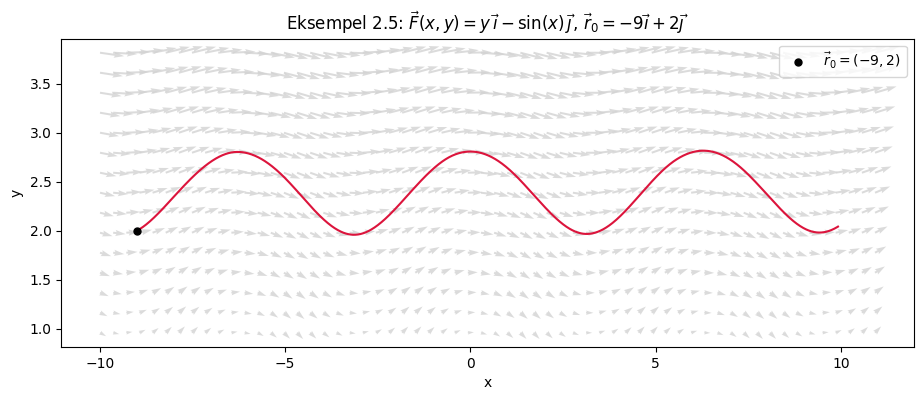

In [8]:
x0, y0 = -9, 2   # startpunktet fra Eksempel 2.5 i kompendiet

t_span_25 = (0, 8)
t_eval_25 = np.linspace(*t_span_25, 1500)
sol25 = solve_ivp(system, t_span_25, [x0, y0], t_eval=t_eval_25)   # løs banen numerisk
x25, y25 = sol25.y[0], sol25.y[1]

E25 = 0.5*y0**2 - np.cos(x0)   # samme energiformel som over
print(f"Energi E = {E25:.2f} (E>1 betyr at pendelen ruller over toppunktet)")

xv = np.linspace(x25.min() - 1, x25.max() + 1, 60)
yv = np.linspace(y25.min() - 1, y25.max() + 1, 15)
X, Y = np.meshgrid(xv, yv)
U, V = F2(X, Y)

fig, ax = plt.subplots(figsize=(11, 4))
ax.quiver(X, Y, U, V, color='lightgray', alpha=0.8)
ax.plot(x25, y25, color='crimson', lw=1.5)
ax.plot(x0, y0, 'o', color='black', ms=5, label=fr"$\vec r_0=({x0},{y0})$")

ax.set_title(r"Eksempel 2.5: $\vec F(x,y)=y\,\vec\imath-\sin(x)\,\vec\jmath$, $\vec r_0=-9\vec\imath+2\vec\jmath$")
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()
plt.show()

**Oppgave (løses i forelesningen):** Legg til flere startpunkter, gjerne med større $|y_0|$. Hva skjer med banene når de får høy nok "energi" -- ser du et skifte fra sirkelformede til bølgeformede baner?

In [9]:
# Skriv koden her


### Kilde, sluk og ren rotasjon i ett og samme felt

Til slutt kombinerer vi tre "elementærstrømninger" fra F11 -- en kilde, et sluk og et rent rotasjonsfelt -- i ett og samme vektorfelt, ved rett og slett å **legge dem sammen**. Dette er nøyaktig samme idé som dekomponeringen i F11 (avsnitt 5), bare med tre bidrag i stedet for to, og plassert i tre forskjellige punkter $A$, $B$ og $C$ i stedet for i origo:

$$\vec F(\vec r) = \underbrace{q_A\frac{\vec r-A}{\lVert\vec r-A\rVert^2}}_{\text{kilde i }A} \;-\; \underbrace{q_B\frac{\vec r-B}{\lVert\vec r-B\rVert^2}}_{\text{sluk i }B} \;+\; \underbrace{\Gamma\frac{(-(y-C_y),\,x-C_x)}{\lVert\vec r-C\rVert^2}}_{\text{ren rotasjon om }C}.$$

Legg merke til at hvert av de tre bidragene er nøyaktig samme type sentralsymmetriske felt som i divergens- og curl-avsnittene i F11 ($C\hat{\vec r}/r$, med $n=1$ i $d=2$ dimensjoner) -- de er altså hver for seg divergensfrie/curlfrie bort fra i sitt eget senter, men gir likevel en tydelig kilde, et tydelig sluk og en tydelig rotasjon å se på strømlinjene, fordi "spesialiteten" bare gjelder de *andre* to punktene sett fra hvert senter.

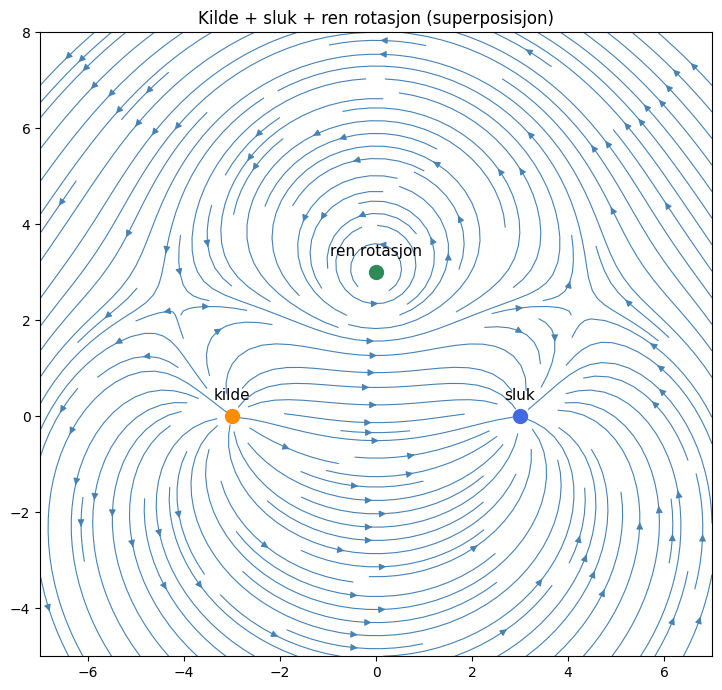

In [10]:
A = np.array([-3.0, 0.0])       # posisjon: kilde
B = np.array([3.0, 0.0])        # posisjon: sluk
Csenter = np.array([0.0, 3.0])  # posisjon: ren rotasjon

qA, qB, Gamma = 3.0, 3.0, 4.0   # styrken på hvert av de tre bidragene

def F_kombinert(x, y):
    # Hvert bidrag er et sentralsymmetrisk felt C*r_hat/r (samme type som i F11,
    # med n=1 i d=2 dimensjoner), sentrert i sitt eget punkt A, B eller Csenter.
    # Vi legger dem ganske enkelt sammen (superposisjon).
    dxA, dyA = x - A[0], y - A[1]
    rA2 = dxA**2 + dyA**2
    dxB, dyB = x - B[0], y - B[1]
    rB2 = dxB**2 + dyB**2
    dxC, dyC = x - Csenter[0], y - Csenter[1]
    rC2 = dxC**2 + dyC**2

    # kilde (+qA), sluk (-qB) og en ren rotasjon (Gamma, rotert 90 grader: (-dy,dx))
    u = qA*dxA/rA2 - qB*dxB/rB2 + Gamma*(-dyC)/rC2
    v = qA*dyA/rA2 - qB*dyB/rB2 + Gamma*(dxC)/rC2
    return u, v

xv = np.linspace(-7, 7, 400)
yv = np.linspace(-5, 8, 400)
X, Y = np.meshgrid(xv, yv)
U, V = F_kombinert(X, Y)

fig, ax = plt.subplots(figsize=(9, 7))
# streamplot, siden feltet "blåser opp" nær hvert av de tre sentrene
ax.streamplot(xv, yv, U, V, density=1.6, color='steelblue', linewidth=0.8, arrowsize=1)
ax.plot(*A, 'o', color='darkorange', ms=10)
ax.plot(*B, 'o', color='royalblue', ms=10)
ax.plot(*Csenter, 'o', color='seagreen', ms=10)
ax.annotate("kilde", A, textcoords="offset points", xytext=(0, 12), ha='center', fontsize=11)
ax.annotate("sluk", B, textcoords="offset points", xytext=(0, 12), ha='center', fontsize=11)
ax.annotate("ren rotasjon", Csenter, textcoords="offset points", xytext=(0, 12), ha='center', fontsize=11)
ax.set_aspect('equal')
ax.set_xlim(-7, 7); ax.set_ylim(-5, 8)
ax.set_title("Kilde + sluk + ren rotasjon (superposisjon)")
plt.tight_layout()
plt.show()

Dette er akkurat samme byggeklosser-idé som brukes i strømningslære (potensialstrømning): kilder, sluk og virvler kan legges sammen fritt for å bygge opp mer kompliserte strømningsmønstre -- for eksempel brukes nettopp en slik superposisjon (kilde + jevn strøm) til å modellere strømning rundt en sylinder eller en vingeprofil.

**Oppgave (løses i forelesningen):** Flytt på $A$, $B$ og $C$, eller endre styrkene `qA`, `qB`, `Gamma`. Hva skjer med bildet dersom $q_A\neq q_B$ (kilden og sluket har ulik styrke)? Hva skjer om du bytter fortegn på $\Gamma$?

In [11]:
# Skriv koden her


## Oppsummering

1. En **potensialfunksjon** $f$ til $\vec F$ oppfyller $\vec F=\nabla f$. Den kan ofte finnes ved å integrere første komponent med hensyn på $x$, og justere med en funksjon $g(y)$ slik at $f_y$ stemmer med andre komponent. Ethvert slikt gradientfelt er automatisk **rotasjonsfritt** ($\operatorname{curl}\vec F=0$).
2. **Strømlinjer/baner** til $\vec F$ løses som en ODE, $\gamma'(t)=\vec F(\gamma(t))$, med `scipy.integrate.solve_ivp`. Strømlinjer til et gradientfelt krysser alltid nivåkurvene til potensialet vinkelrett. Flere elementærstrømninger (kilde, sluk, ren rotasjon) kan superponeres til mer kompliserte strømningsmønstre -- hver for seg divergensfrie/rotasjonsfrie bort fra i sitt eget sentrum.

Dette bygger direkte på vektorfelt, gradient, divergens og curl fra `F11_Gradient_Vektorfelt_Divergens_Curl.ipynb`. Neste steg -- linjeintegraler og den presise definisjonen av **konservative vektorfelt** -- finner du i `F13`.